# Movie Recommendation for Streaming Platform
## Notebook 3 — Collaborative Filtering, SVD & Evaluation

**What this notebook does:**
1. Rebuilds your original User-Based CF (cosine similarity + weighted average) — taken directly from your code
2. Adds SVD (Matrix Factorisation) as an upgraded CF method
3. Evaluates both methods using RMSE, MAE, Precision@K and Recall@K
4. Compares the two methods side-by-side

Run `1_EDA.ipynb` first to generate `merged_data.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.sparse.linalg import svds

sns.set_theme(style='whitegrid')

In [2]:
# Load the merged dataset saved by Notebook 1
data = pd.read_csv(r'C:\Movie Recommendation project\data\merged_data.csv')
print('Data loaded:', data.shape)

Data loaded: (1000209, 11)


---
# Part A — Your Original User-Based Collaborative Filtering
This is your existing code, kept exactly as you wrote it.

In [3]:
# Build user-movie matrix on the full dataset
user_movie_matrix = data.pivot_table(index='user_id', columns='title', values='rating').fillna(0)
print('User-movie matrix shape:', user_movie_matrix.shape)

User-movie matrix shape: (6040, 3706)


In [4]:
# Compute cosine similarity between all users
user_similarity    = cosine_similarity(user_movie_matrix)
user_similarity_df = pd.DataFrame(user_similarity,
                                   index=user_movie_matrix.index,
                                   columns=user_movie_matrix.index)
print('User similarity matrix shape:', user_similarity_df.shape)

User similarity matrix shape: (6040, 6040)


In [5]:
# Your recommend_movies function — weighted average, removes watched movies
def recommend_movies(user_id, n=10):
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)
    similar_users = similar_users[similar_users >= 0.3]        # similarity threshold
    similar_users = similar_users[similar_users.index != user_id]  # exclude self
    similar_users = similar_users.head(5)                      # top 5

    if len(similar_users) == 0:
        print(f'No similar users found for user {user_id}')
        return pd.Series(dtype=float)

    similar_user_movies = user_movie_matrix.loc[similar_users.index]

    # Weighted average: weight each user's ratings by similarity score
    weights          = similar_users.to_numpy()
    weighted_ratings = similar_user_movies.T.dot(weights) / weights.sum()

    recommended = pd.Series(weighted_ratings, index=user_movie_matrix.columns)
    recommended = recommended.sort_values(ascending=False)

    # Remove movies the user has already rated
    watched = user_movie_matrix.loc[user_id][user_movie_matrix.loc[user_id] > 0].index
    recommended = recommended[~recommended.index.isin(watched)]

    return recommended.head(n)


print('=== Cosine Similarity CF — Recommendations for User 10 ===')
print(recommend_movies(10))

=== Cosine Similarity CF — Recommendations for User 10 ===
title
Muppet Movie, The (1979)                  4.622861
Babe (1995)                               4.572957
Hunt for Red October, The (1990)          4.434220
Saving Private Ryan (1998)                4.237774
American Tail, An (1986)                  4.237774
Dave (1993)                               4.229968
Romancing the Stone (1984)                4.195818
Love Bug, The (1969)                      4.188012
Star Trek V: The Final Frontier (1989)    4.007806
Liar Liar (1997)                          4.000487
dtype: float64


---
# Part B — SVD (Matrix Factorisation) — Upgraded CF

SVD is still Collaborative Filtering — it just works differently.
Instead of finding similar users directly, it discovers hidden 'tastes' (latent factors)
shared across users and movies, and uses those to predict ratings.

```
User-Movie Matrix  ≈  U  ×  Σ  ×  Vt
                       ↑       ↑
                    user       movie
                   factors    factors
```

### Step B1 — Train / Test Split
We hold out 20% of ratings. The SVD model trains only on the 80% training set.
Evaluation is done on the 20% the model has never seen.

In [6]:
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

print(f'Training samples : {len(train_data):,}')
print(f'Test samples     : {len(test_data):,}')

Training samples : 800,167
Test samples     : 200,042


### Step B2 — Build Train Matrix and Apply SVD

In [7]:
# Build matrix from TRAINING data only
train_matrix = train_data.pivot_table(
    index='user_id', columns='title', values='rating'
).fillna(0)

print('Train matrix shape:', train_matrix.shape)

# Centre ratings by subtracting each user's mean (removes rating bias)
matrix_values      = train_matrix.values
user_ratings_mean  = matrix_values.mean(axis=1)
R_demeaned         = matrix_values - user_ratings_mean.reshape(-1, 1)

# SVD decomposition — k=50 latent factors
k = 50
U, sigma, Vt = svds(R_demeaned, k=k)

# Reconstruct predicted ratings matrix
sigma_diag       = np.diag(sigma)
predicted_arr    = np.dot(np.dot(U, sigma_diag), Vt) + user_ratings_mean.reshape(-1, 1)
preds_df         = pd.DataFrame(predicted_arr,
                                 columns=train_matrix.columns,
                                 index=train_matrix.index)

print('SVD complete. Predictions shape:', preds_df.shape)

Train matrix shape: (6040, 3683)
SVD complete. Predictions shape: (6040, 3683)


### Step B3 — SVD Recommendation Function

In [8]:
def svd_recommend(user_id, n=10):
    if user_id not in preds_df.index:
        print(f'User {user_id} not in training data.')
        return pd.Series(dtype=float)

    # Exclude movies already rated in training
    already_rated = train_matrix.loc[user_id][train_matrix.loc[user_id] > 0].index
    user_preds    = preds_df.loc[user_id].drop(labels=already_rated, errors='ignore')

    return user_preds.sort_values(ascending=False).head(n)


print('=== SVD Recommendations for User 10 ===')
print(svd_recommend(10))

=== SVD Recommendations for User 10 ===
title
Groundhog Day (1993)               4.231912
Who Framed Roger Rabbit? (1988)    3.567428
Lady and the Tramp (1955)          3.495576
Romancing the Stone (1984)         3.438717
Princess Bride, The (1987)         3.351355
Spaceballs (1987)                  3.333945
Rain Man (1988)                    3.162045
Airplane! (1980)                   3.090774
Muppet Movie, The (1979)           3.081265
To Kill a Mockingbird (1962)       3.022172
Name: 10, dtype: float64


---
# Part C — Evaluation Metrics

Evaluation metrics are **not** a recommendation method — they measure how good a method is.
We apply them to the SVD predictions against the held-out test set.

| Metric | Measures | Better when |
|---|---|---|
| RMSE | Rating prediction error (penalises big errors) | Lower |
| MAE  | Rating prediction error (average error)        | Lower |
| Precision@K | % of top-K recommendations the user liked | Higher |
| Recall@K    | % of liked movies caught in top-K list    | Higher |

### Step C1 — RMSE and MAE

In [9]:
actual_list    = []
predicted_list = []

for _, row in test_data.iterrows():
    uid   = row['user_id']
    title = row['title']
    if uid in preds_df.index and title in preds_df.columns:
        actual_list.append(row['rating'])
        predicted_list.append(preds_df.loc[uid, title])

actual_arr = np.array(actual_list)
pred_arr   = np.array(predicted_list)

rmse = np.sqrt(mean_squared_error(actual_arr, pred_arr))
mae  = mean_absolute_error(actual_arr, pred_arr)

print(f'Evaluated on {len(actual_arr):,} test ratings')
print(f'RMSE : {rmse:.4f}  (lower is better — avg error in rating units)')
print(f'MAE  : {mae:.4f}  (lower is better — avg absolute error)')

Evaluated on 200,016 test ratings
RMSE : 2.7405  (lower is better — avg error in rating units)
MAE  : 2.4678  (lower is better — avg absolute error)


### Step C2 — Visualize Predicted vs Actual Ratings

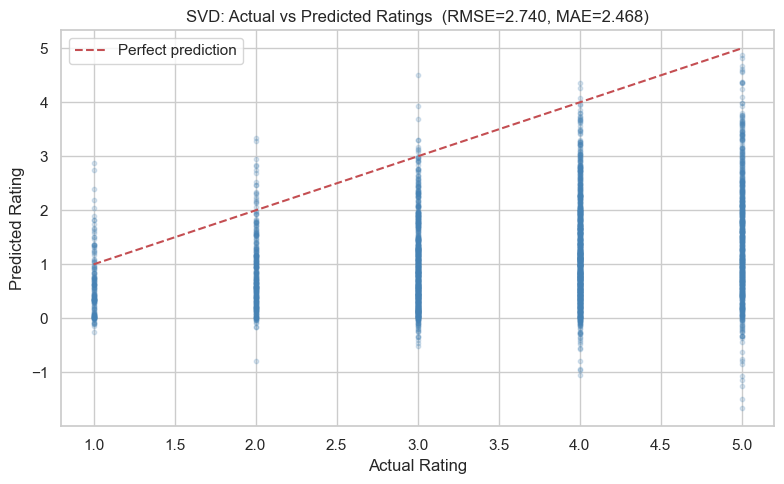

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(actual_arr[:3000], pred_arr[:3000], alpha=0.2, s=10, color='steelblue')
plt.plot([1, 5], [1, 5], 'r--', label='Perfect prediction')
plt.title(f'SVD: Actual vs Predicted Ratings  (RMSE={rmse:.3f}, MAE={mae:.3f})')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.legend()
plt.tight_layout()
plt.show()

### Step C3 — Precision@K and Recall@K

We define a movie as 'liked' if the user rated it ≥ 4.

In [11]:
def precision_recall_at_k(preds_df, test_data, k=10, threshold=4.0):
    precisions, recalls = [], []

    for user_id, user_test in test_data.groupby('user_id'):
        if user_id not in preds_df.index:
            continue

        liked_movies = set(user_test[user_test['rating'] >= threshold]['title'])
        if not liked_movies:
            continue

        top_k_preds = set(
            preds_df.loc[user_id].sort_values(ascending=False).head(k).index
        )
        hits = liked_movies & top_k_preds

        precisions.append(len(hits) / k)
        recalls.append(len(hits) / len(liked_movies))

    return np.mean(precisions) if precisions else 0.0, \
           np.mean(recalls)    if recalls    else 0.0


K = 10
prec, rec = precision_recall_at_k(preds_df, test_data, k=K, threshold=4.0)

print(f'Precision@{K} : {prec:.4f}  → {prec*100:.1f}% of top-{K} recs were liked by the user')
print(f'Recall@{K}    : {rec:.4f}  → {rec*100:.1f}% of liked movies appeared in the top-{K}')

Precision@10 : 0.0409  → 4.1% of top-10 recs were liked by the user
Recall@10    : 0.0541  → 5.4% of liked movies appeared in the top-10


### Step C4 — Precision@K across Different K Values

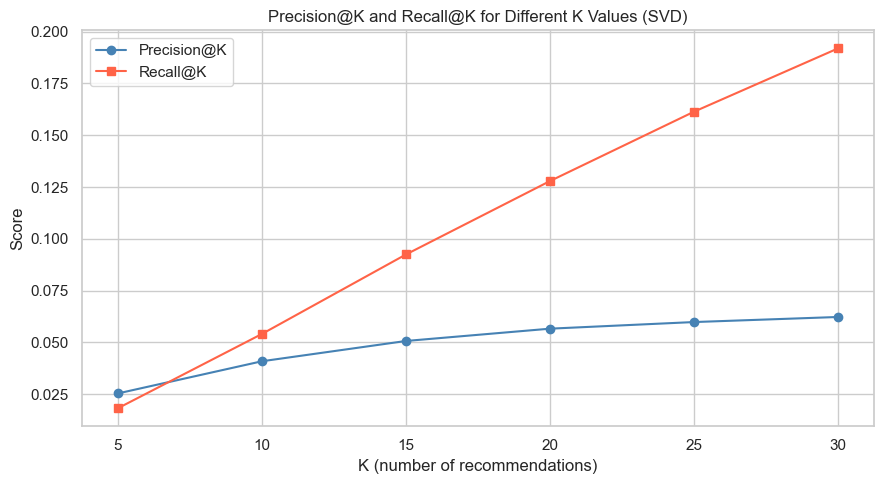

In [12]:
k_values   = [5, 10, 15, 20, 25, 30]
precisions = []
recalls    = []

for k in k_values:
    p, r = precision_recall_at_k(preds_df, test_data, k=k, threshold=4.0)
    precisions.append(p)
    recalls.append(r)

plt.figure(figsize=(9, 5))
plt.plot(k_values, precisions, marker='o', label='Precision@K', color='steelblue')
plt.plot(k_values, recalls,    marker='s', label='Recall@K',    color='tomato')
plt.title('Precision@K and Recall@K for Different K Values (SVD)')
plt.xlabel('K (number of recommendations)')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.show()

---
# Part D — Side-by-Side Comparison
Compare what both methods recommend for the same user.

In [13]:
TEST_USER = 10

cosine_recs = recommend_movies(TEST_USER)
svd_recs    = svd_recommend(TEST_USER)

comparison = pd.DataFrame({
    'Cosine Similarity CF'  : cosine_recs.reset_index()['title'] if len(cosine_recs) > 0 else ['—']*10,
    'SVD (Matrix Factorisation)': svd_recs.reset_index()['title']
})
comparison.index = [f'Rank {i+1}' for i in range(len(comparison))]

print(f'=== Recommendations for User {TEST_USER} ===')
print(comparison.to_string())

=== Recommendations for User 10 ===
                           Cosine Similarity CF       SVD (Matrix Factorisation)
Rank 1                 Muppet Movie, The (1979)             Groundhog Day (1993)
Rank 2                              Babe (1995)  Who Framed Roger Rabbit? (1988)
Rank 3         Hunt for Red October, The (1990)        Lady and the Tramp (1955)
Rank 4               Saving Private Ryan (1998)       Romancing the Stone (1984)
Rank 5                 American Tail, An (1986)       Princess Bride, The (1987)
Rank 6                              Dave (1993)                Spaceballs (1987)
Rank 7               Romancing the Stone (1984)                  Rain Man (1988)
Rank 8                     Love Bug, The (1969)                 Airplane! (1980)
Rank 9   Star Trek V: The Final Frontier (1989)         Muppet Movie, The (1979)
Rank 10                        Liar Liar (1997)     To Kill a Mockingbird (1962)


---
## Final Summary

| Method | Approach | Evaluation |
|---|---|---|
| User-Based CF (cosine similarity) | Finds similar users, weighted avg | No train/test split — qualitative only |
| SVD (Matrix Factorisation) | Latent factors from decomposition | RMSE, MAE, Precision@K, Recall@K |

Both are Collaborative Filtering — SVD is simply a more robust version that handles sparse data better.

**How to interpret your scores:**
- RMSE < 1.0 is considered good for a 1–5 rating scale
- Precision@10 > 0.10 (10%) means 1 in 10 recommendations is relevant — acceptable baseline
- Recall@10 tells you how much of the user's taste you're capturing